In [1]:
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import easyocr

from ultralytics import YOLO

from py_files.detection import extract_plate
from py_files.preprocessing import preprocess_plate
from py_files.ocr import recognize_plate

In [2]:
model = YOLO("../models/best.pt")

reader = easyocr.Reader(
    ["en"],
    gpu=False
)

Using CPU. Note: This module is much faster with a GPU.


In [3]:
val_folder = Path("../data/cars/images/val")

images = list(val_folder.glob("*.jpg"))

print(len(images))

1073


In [4]:
random.seed(42)

sample_images = random.sample(
    images,
    20
)

len(sample_images)

20

In [5]:
methods = [
    "baseline",
    "equalize",
    "clahe",
    "otsu",
    "adaptive",
    "clahe_otsu"
]

In [8]:
import importlib
import py_files.detection

importlib.reload(py_files.detection)

from py_files.detection import extract_plate

In [9]:
rows = []

for image_path in sample_images:

    plates = extract_plate(
        image_path,
        model
    )

    if len(plates) == 0:
        continue

    plate = plates[0]

    for method in methods:

        processed = preprocess_plate(
            plate,
            method=method
        )

        text, conf = recognize_plate(
            processed,
            reader
        )

        rows.append({
            "image": image_path.name,
            "method": method,
            "prediction": text,
            "confidence": conf
        })


image 1/1 C:\Users\User\PycharmProjects\JupyterProject\notebooks\..\data\cars\images\val\2c602008a22124be.jpg: 544x640 4 license_plates, 184.6ms
Speed: 27.0ms preprocess, 184.6ms inference, 3.2ms postprocess per image at shape (1, 3, 544, 640)


C:\Users\User\PycharmProjects\JupyterProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



image 1/1 C:\Users\User\PycharmProjects\JupyterProject\notebooks\..\data\cars\images\val\03ae238ae9016ff5.jpg: 640x480 1 license_plate, 72.7ms
Speed: 3.4ms preprocess, 72.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 C:\Users\User\PycharmProjects\JupyterProject\notebooks\..\data\cars\images\val\83c416344cb2ae4e.jpg: 480x640 1 license_plate, 72.3ms
Speed: 2.1ms preprocess, 72.3ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\User\PycharmProjects\JupyterProject\notebooks\..\data\cars\images\val\73b689066698d3a2.jpg: 480x640 1 license_plate, 56.8ms
Speed: 2.4ms preprocess, 56.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\User\PycharmProjects\JupyterProject\notebooks\..\data\cars\images\val\695582dbb6b564bc.jpg: 448x640 2 license_plates, 75.7ms
Speed: 2.5ms preprocess, 75.7ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\User\PycharmPro

In [10]:
results = pd.DataFrame(rows)

results.head()

,image,method,prediction,confidence
0,2c602008a22124be.jpg,baseline,5543736,0.663598
1,2c602008a22124be.jpg,equalize,554413486,0.171922
2,2c602008a22124be.jpg,clahe,55443736,0.424308
3,2c602008a22124be.jpg,otsu,NaN,NaN
4,2c602008a22124be.jpg,adaptive,584373,0.249854


In [11]:
results.groupby(
    "method"
)["confidence"].mean().sort_values(
    ascending=False
)

method
baseline      0.563953
clahe         0.538220
equalize      0.469285
otsu          0.447313
adaptive      0.422109
clahe_otsu    0.392405
Name: confidence, dtype: float64

<Figure size 1000x500 with 0 Axes>

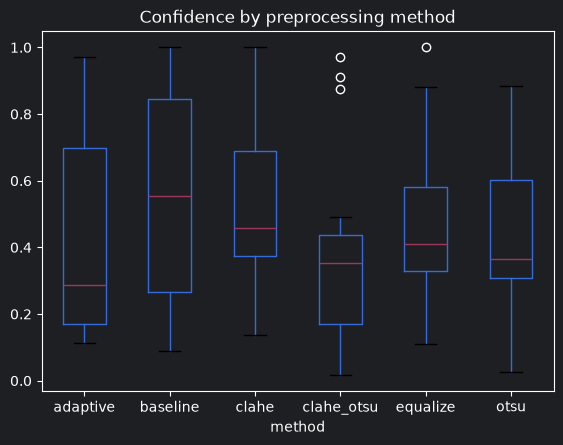

In [12]:
plt.figure(figsize=(10,5))

results.boxplot(
    column="confidence",
    by="method",
    grid=False
)

plt.suptitle("")
plt.title("Confidence by preprocessing method")

plt.show()

In [13]:
results.sort_values(
    "confidence"
).head(20)

,image,method,prediction,confidence
5,2c602008a22124be.jpg,clahe_otsu,Q5FHK,0.017885
75,674c38686cee30aa.jpg,otsu,E9,0.026785
18,73b689066698d3a2.jpg,baseline,EAP,0.087592
67,23fa8a0b6d60d9a0.jpg,equalize,FI50284540,0.109046
83,6e2a8d5a176af75e.jpg,clahe_otsu,CL486,0.110160
58,06bf917a1448f872.jpg,adaptive,TISC7S97,0.113641
76,674c38686cee30aa.jpg,adaptive,78381H,0.136388
68,23fa8a0b6d60d9a0.jpg,clahe,F5028410,0.136821
53,cafc97ebc49704ba.jpg,clahe_otsu,EB7E552,0.138354
81,6e2a8d5a176af75e.jpg,otsu,F26,0.140218


In [ ]:
mean_conf = (
    results.groupby("method")["confidence"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))

mean_conf.plot(kind="bar")

plt.ylabel("Mean confidence")

plt.title("Average OCR confidence")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

for method in methods:

    subset = results[
        results.method == method
    ]

    plt.hist(
        subset.confidence,
        bins=10,
        alpha=0.4,
        label=method
    )

plt.legend()

plt.xlabel("Confidence")

plt.show()